# UniStitch: Matching & Image Stitching (epoch-0 ALIKED model)

- **Model**: `outputs/finetune_aliked_amuse2/checkpoints/best_epoch0001_ssim0.6785.pth`
  (AMUSE averaged iterate after epoch 0 of the UDIS-D ALIKED fine-tune)

> **Note**: the `ssim0.6785` / `ssim0.6983` numbers embedded in early
> checkpoint filenames come from validation runs affected by an index-vs-name
> pairing bug in `Codes/dataset.py` (UDIS-D testing `input1` misses
> `000001.jpg`, which shifted index-based pairing by one). With the fixed
> name-based pairing the same weights score ~0.80-0.90 mSSIM. The checkpoint
> weights themselves are unaffected.
>
> Reference (full UDIS-D testing, 1,105 pairs, fixed pairing): released
> baseline mSSIM **0.8070** / mPSNR **24.87** (paper: 0.813 / 25.07).

The notebook auto-discovers checkpoints: `baseline` (released), `epoch0`
(newest `best_epoch0001_*.pth`) and `latest_best` (newest
`outputs/**/checkpoints/best.pth`). `Codes/checkpoint_utils.py` adapts the
descriptor stem, so both 256-d (zero-padded ALIKED) and native 128-d
checkpoints load.

Run with the pixi environment:

```bash
pixi run lab                     # or:
pixi run jupyter nbconvert --to notebook --execute --inplace notebooks/matching_and_stitching_epoch0.ipynb
```

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("CUDA_VISIBLE_DEVICES", "1")  # GPU0 may be busy; use GPU1
os.environ.setdefault("MPLBACKEND", "Agg")


def find_root(start: Path = Path.cwd()) -> Path:
    for path in [start, *start.parents]:
        if (path / "Codes" / "network.py").exists():
            return path
    raise RuntimeError("repository root not found")


ROOT = find_root()
sys.path.insert(0, str(ROOT / "Codes"))
sys.path.insert(0, str(ROOT / "keypoint_tool"))

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch

FIG_DIR = ROOT / "notebooks" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_BASELINE = ROOT / "model_homo_stage2" / "epoch_best_model.pth"
CHECKPOINT_ENTRIES = {"baseline": CHECKPOINT_BASELINE}

_epoch0 = sorted((ROOT / "outputs/finetune_aliked_amuse2/checkpoints").glob("best_epoch0001_*.pth"))
if _epoch0:
    CHECKPOINT_ENTRIES["epoch0"] = _epoch0[-1]

_best_links = sorted((ROOT / "outputs").glob("**/checkpoints/best.pth"), key=lambda path: path.stat().st_mtime)
if _best_links:
    _latest = _best_links[-1].resolve()
    if _latest not in CHECKPOINT_ENTRIES.values():
        CHECKPOINT_ENTRIES["latest_best"] = _latest

for name, checkpoint in CHECKPOINT_ENTRIES.items():
    print(f"{name}: {checkpoint.name} (exists={checkpoint.exists()})")
print("torch", torch.__version__, "| cuda available:", torch.cuda.is_available())

baseline: epoch_best_model.pth (exists=True)
epoch0: best_epoch0001_ssim0.6785.pth (exists=True)
latest_best: best_epoch0002_ssim0.6983.pth (exists=True)
torch 2.14.0+cu130 | cuda available: True


## 1. Sample pairs

Two UDIS-D testing pairs and one classical (large-baseline) pair.

In [2]:
SAMPLE_PAIRS = {
    "udis_000002": (
        ROOT / "data/UDIS-D/testing/input1/000002.jpg",
        ROOT / "data/UDIS-D/testing/input2/000002.jpg",
    ),
    "udis_000005": (
        ROOT / "data/UDIS-D/testing/input1/000005.jpg",
        ROOT / "data/UDIS-D/testing/input2/000005.jpg",
    ),
    "classical_000004": (
        ROOT / "data/classical_tmp/stitch_real/input1/000004.jpg",
        ROOT / "data/classical_tmp/stitch_real/input2/000004.jpg",
    ),
}


def read_rgb(path: Path) -> np.ndarray:
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


for name, (path1, path2) in SAMPLE_PAIRS.items():
    image0, image1 = read_rgb(path1), read_rgb(path2)
    print(f"{name}: {image0.shape} / {image1.shape}")

udis_000002: (512, 512, 3) / (512, 512, 3)
udis_000005: (512, 512, 3) / (512, 512, 3)
classical_000004: (662, 1000, 3) / (662, 1000, 3)


## 2. Keypoint matching (RaCo-ALIKED-LightGlue+ v3.0, ONNX)

The self-contained ONNX pipeline detects RaCo keypoints, matches them with
LightGlue+ and samples ALIKED descriptors (`keypoint_tool/onnx_models.py`).

In [3]:
from onnx_models import RaCoAlikedLightGlue

# Force CPU: GPU1 is busy with training and ORT's CUDA arena cannot fit alongside it.
matcher = RaCoAlikedLightGlue(num_threads=8, providers=["CPUExecutionProvider"])

match_results = {}
for name, (path1, path2) in SAMPLE_PAIRS.items():
    image0, image1 = read_rgb(path1), read_rgb(path2)
    result = matcher.match_pair(image0, image1, max_side=1024)
    match_results[name] = result
    print(f"{name}: {len(result['keypoints0'])} matches ({result['descriptors0'].shape[1]}-d descriptors)")

2026-09-14 20:05:57.799388160 [W:onnxruntime:, constant_folding.cc:581 ApplyImpl] Could not find a CPU kernel and hence can't constant fold CastLike node 'node_CastLike_126'
2026-09-14 20:05:57.799466591 [W:onnxruntime:, constant_folding.cc:581 ApplyImpl] Could not find a CPU kernel and hence can't constant fold CastLike node 'node_CastLike_124'
2026-09-14 20:05:57.800555229 [W:onnxruntime:, constant_folding.cc:581 ApplyImpl] Could not find a CPU kernel and hence can't constant fold CastLike node 'node_CastLike_210'
2026-09-14 20:05:57.800586000 [W:onnxruntime:, constant_folding.cc:581 ApplyImpl] Could not find a CPU kernel and hence can't constant fold CastLike node 'node_CastLike_209'
2026-09-14 20:05:57.835183525 [W:onnxruntime:, constant_folding.cc:581 ApplyImpl] Could not find a CPU kernel and hence can't constant fold CastLike node 'node_CastLike_3983'
2026-09-14 20:05:57.835234165 [W:onnxruntime:, constant_folding.cc:581 ApplyImpl] Could not find a CPU kernel and hence can't con

udis_000002: 523 matches (128-d descriptors)


udis_000005: 1261 matches (128-d descriptors)


classical_000004: 443 matches (128-d descriptors)


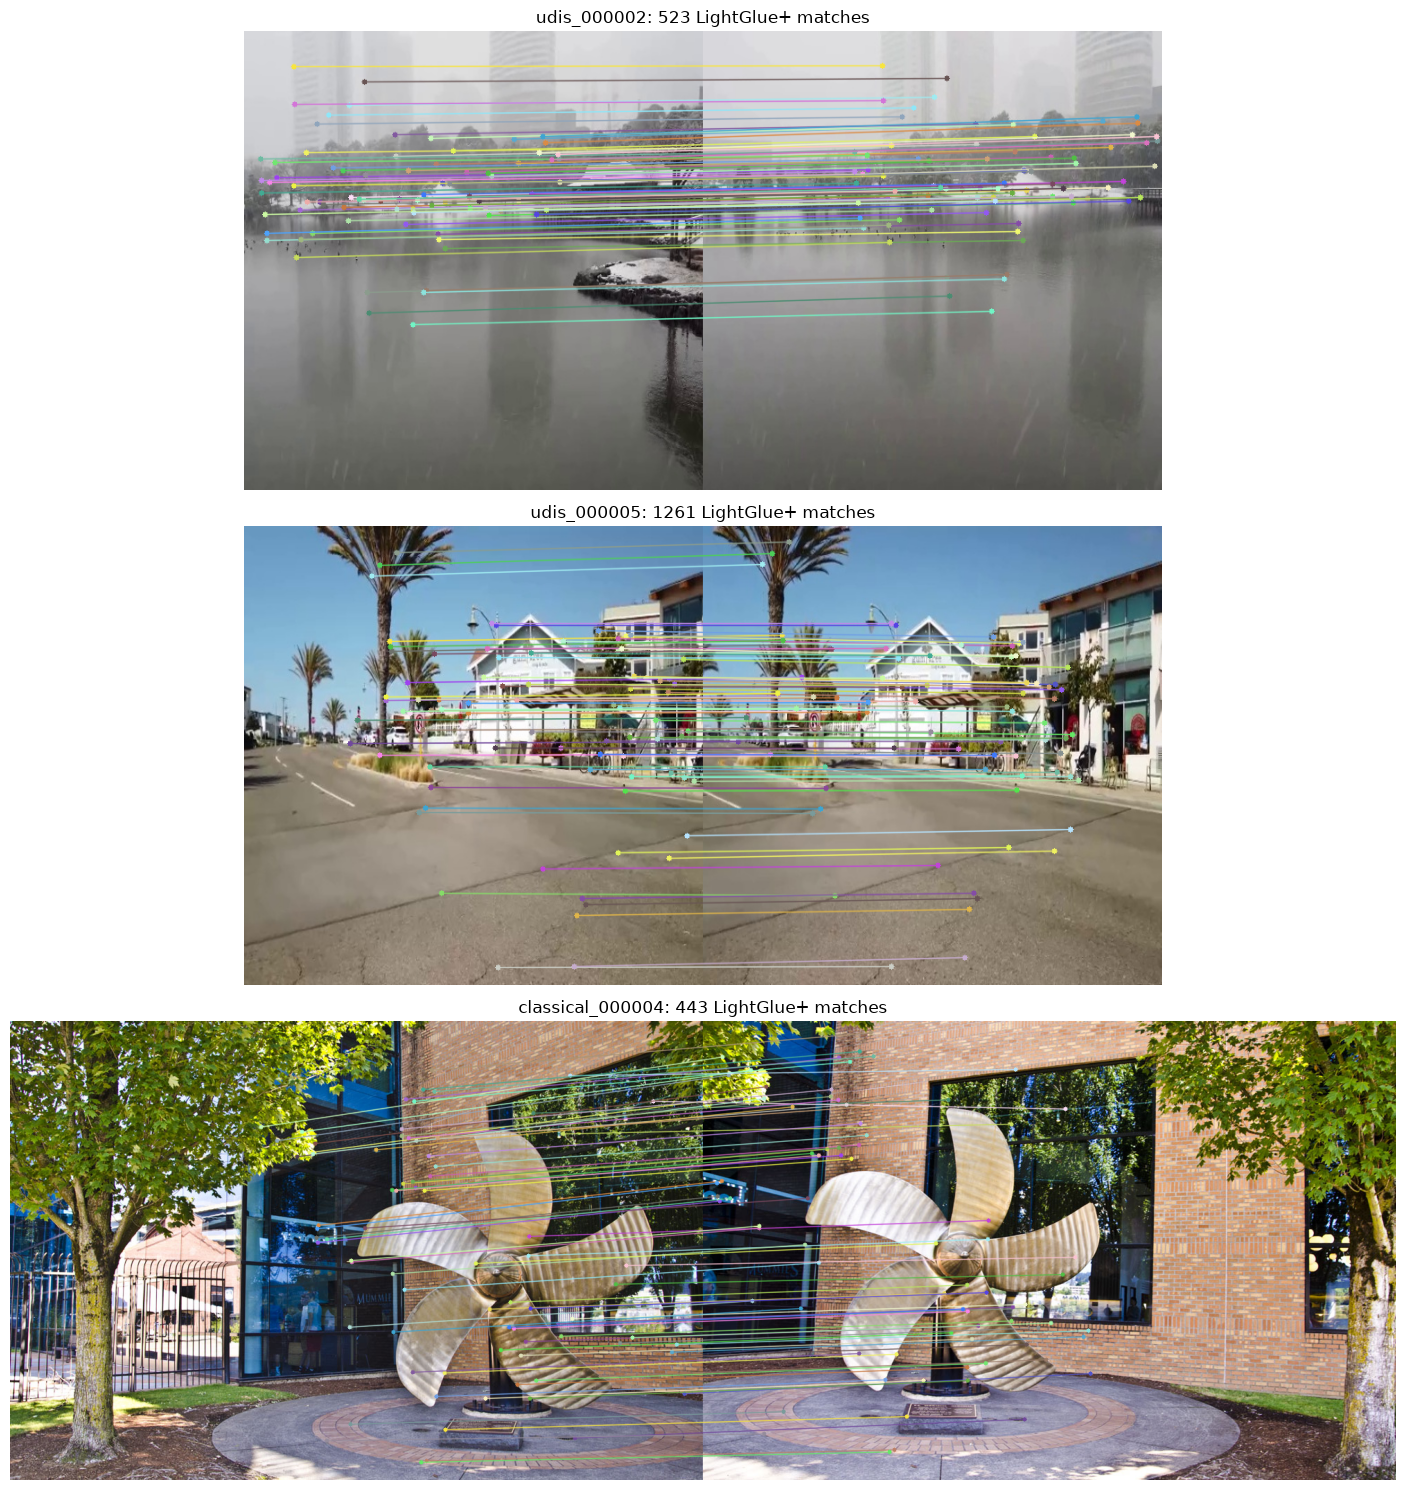

In [4]:
def draw_matches(image0: np.ndarray, image1: np.ndarray, points0: np.ndarray, points1: np.ndarray, max_draw: int = 80):
    canvas = np.concatenate([image0, image1], axis=1)
    width0 = image0.shape[1]
    rng = np.random.default_rng(0)
    indices = rng.choice(len(points0), size=min(max_draw, len(points0)), replace=False)
    for index in indices:
        p0 = tuple(np.round(points0[index]).astype(int))
        p1 = tuple(np.round(points1[index]).astype(int))
        color = tuple(int(value) for value in rng.integers(60, 255, size=3))
        cv2.line(canvas, p0, (p1[0] + width0, p1[1]), color, 1, cv2.LINE_AA)
        cv2.circle(canvas, p0, 3, color, -1)
        cv2.circle(canvas, (p1[0] + width0, p1[1]), 3, color, -1)
    return canvas


figure, axes = plt.subplots(len(SAMPLE_PAIRS), 1, figsize=(16, 5 * len(SAMPLE_PAIRS)))
for axis, (name, (path1, path2)) in zip(np.ravel(axes), SAMPLE_PAIRS.items()):
    result = match_results[name]
    canvas = draw_matches(read_rgb(path1), read_rgb(path2), result["keypoints0"], result["keypoints1"])
    axis.imshow(canvas)
    axis.set_title(f"{name}: {len(result['keypoints0'])} LightGlue+ matches")
    axis.axis("off")
figure.tight_layout()
figure.savefig(FIG_DIR / "matches_epoch0.png", dpi=110)
plt.show()

## 3. Stitching (fine-tuned ALIKED models vs. released baseline)

Keypoints/descriptors come from the `aliked_lmdb` built with the same ONNX
pipeline. Descriptors are zero-padded per model (`pad_descriptor_dim`), so both
256-d (warm-start with the 256-d stem) and native 128-d checkpoints work. The
stitched output is the overlap-weighted fusion of the two bidirectionally warped
TPS results.

**Color space**: `Codes/dataset.py` reads images with `cv2.imread`, so the
network (and the fused output) is **BGR**. Figures convert to RGB once for
matplotlib; JPEGs are written directly with `cv2.imwrite` (BGR in, correct
colors out).

In [5]:
from checkpoint_utils import infer_descriptor_dim, load_model_state
from dataset import TestDataset, pad_descriptor_dim
from network import Network, build_output_model
from skimage.metrics import structural_similarity


def load_network(checkpoint_path: Path) -> tuple[torch.nn.Module, int]:
    checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    state = checkpoint["model"] if isinstance(checkpoint, dict) and "model" in checkpoint else checkpoint
    descriptor_dim = infer_descriptor_dim(state)
    net = Network(descriptor_dim=descriptor_dim)
    load_model_state(net, state)
    net.eval()
    net.fuse()
    return net.cuda(), descriptor_dim


def mask_ssim(image1: np.ndarray, image2: np.ndarray, mask: np.ndarray) -> float:
    _, ssim = structural_similarity(image1 * mask, image2 * mask, data_range=255, channel_axis=2, full=True)
    return float(np.sum(ssim * mask) / (np.sum(mask) + 1e-6))


def mask_psnr(image1: np.ndarray, image2: np.ndarray, mask: np.ndarray) -> float:
    image1 = image1 * mask / 255.0
    image2 = image2 * mask / 255.0
    rmse = np.sqrt(np.sum((image1 - image2) ** 2) / mask.sum())
    return float(20 * np.log10(1.0 / rmse))


def stitch_pair(net, descriptor_dim: int, dataset: TestDataset, index: int, max_out_height: int = 6000):
    batch = dataset[index]
    inputs = [value.float() for value in batch[:6]]
    inputs[4] = pad_descriptor_dim(inputs[4], descriptor_dim)
    inputs[5] = pad_descriptor_dim(inputs[5], descriptor_dim)
    inputs = [value.unsqueeze(0).cuda() for value in inputs]
    with torch.no_grad():
        batch_out, flag_check = build_output_model(net, *inputs, max_out_height=max_out_height)
    if not flag_check:
        return None
    output_ref = (batch_out["output_tps_ref"][0, 0:3] * 127.5).clamp(0, 255).cpu().numpy().transpose(1, 2, 0)
    output_tgt = (batch_out["output_tps_tgt"][0, 0:3] * 127.5).clamp(0, 255).cpu().numpy().transpose(1, 2, 0)
    overlap = (batch_out["output_tps_ref"][0, 3:6] * batch_out["output_tps_tgt"][0, 3:6]).cpu().numpy().transpose(1, 2, 0)
    fused = output_ref * (output_ref / (output_ref + output_tgt + 1e-6)) + output_tgt * (
        output_tgt / (output_ref + output_tgt + 1e-6)
    )
    del inputs, batch_out
    torch.cuda.empty_cache()
    fused_bgr = np.clip(fused, 0, 255).astype(np.uint8)
    return {
        "fused_bgr": fused_bgr,
        "fused_rgb": cv2.cvtColor(fused_bgr, cv2.COLOR_BGR2RGB),
        "ssim": mask_ssim(output_ref, output_tgt, overlap),
        "psnr": mask_psnr(output_ref, output_tgt, overlap),
    }


udis_dataset = TestDataset(
    data_path=str(ROOT / "data/UDIS-D/testing"), keypoint="aliked", descriptor_pad_dim=0, resize_max_side=1280
)
classical_dataset = TestDataset(
    data_path=str(ROOT / "data/classical_tmp/stitch_real"),
    keypoint="aliked",
    descriptor_pad_dim=0,
    resize_max_side=1280,
)


def dataset_index(dataset: TestDataset, filename: str) -> int:
    names = [Path(path).name for path in dataset.datas["input1"]["image"]]
    return names.index(filename)


DATASETS = {
    "udis_000002": (udis_dataset, dataset_index(udis_dataset, "000002.jpg")),
    "udis_000005": (udis_dataset, dataset_index(udis_dataset, "000005.jpg")),
    "classical_000004": (classical_dataset, dataset_index(classical_dataset, "000004.jpg")),
}
print({name: index for name, (_, index) in DATASETS.items()})

Loaded LMDB database from /workspace/UniStitch/data/UDIS-D/testing/aliked_lmdb
Test dataset keys: odict_keys(['input1', 'input2'])
Total test samples: 1105
Loaded LMDB database from /workspace/UniStitch/data/classical_tmp/stitch_real/aliked_lmdb
Test dataset keys: odict_keys(['input1', 'input2'])
Total test samples: 147
{'udis_000002': 0, 'udis_000005': 3, 'classical_000004': 3}


In [6]:
networks = {name: load_network(checkpoint) for name, checkpoint in CHECKPOINT_ENTRIES.items()}
for name, (_, descriptor_dim) in networks.items():
    print(f"{name}: descriptor_dim={descriptor_dim}")

results = {}
for model_name, (net, descriptor_dim) in networks.items():
    for sample_name, (dataset, index) in DATASETS.items():
        outcome = stitch_pair(net, descriptor_dim, dataset, index)
        if outcome is None:
            print(f"{model_name}/{sample_name}: skipped (warp too large)")
            continue
        results[(model_name, sample_name)] = outcome
        cv2.imwrite(str(FIG_DIR / f"fused_{sample_name}_{model_name}.jpg"), outcome["fused_bgr"])
        print(f"{model_name}/{sample_name}: ssim={outcome['ssim']:.4f} psnr={outcome['psnr']:.4f}")

loaded 628 tensors, skipped 0, missing 0 (strict=False)
Fusing layers... 


loaded 628 tensors, skipped 0, missing 0 (strict=False)
Fusing layers... 


loaded 628 tensors, skipped 0, missing 0 (strict=False)
Fusing layers... 


baseline: descriptor_dim=256
epoch0: descriptor_dim=256
latest_best: descriptor_dim=256


waring, wrong norm. xyz: torch.Size([1, 2, 2048]) tensor(1.0021, device='cuda:0') tensor(0.0007, device='cuda:0')


...

epoch0/udis_000005: ssim=0.8926 psnr=25.7275


epoch0/classical_000004: ssim=0.2923 psnr=13.3781
waring, wrong norm. xyz: torch.Size([1, 2, 2048]) tensor(1.0021, device='cuda:0') tensor(0.0007, device='cuda:0')


latest_best/udis_000002: ssim=0.9299 psnr=32.5184
waring, wrong norm. xyz: torch.Size([1, 2, 2048]) tensor(1.0007, device='cuda:0') tensor(0.0168, device='cuda:0')


latest_best/udis_000005: ssim=0.9018 psnr=26.1364


latest_best/classical_000004: ssim=0.2905 psnr=13.4096


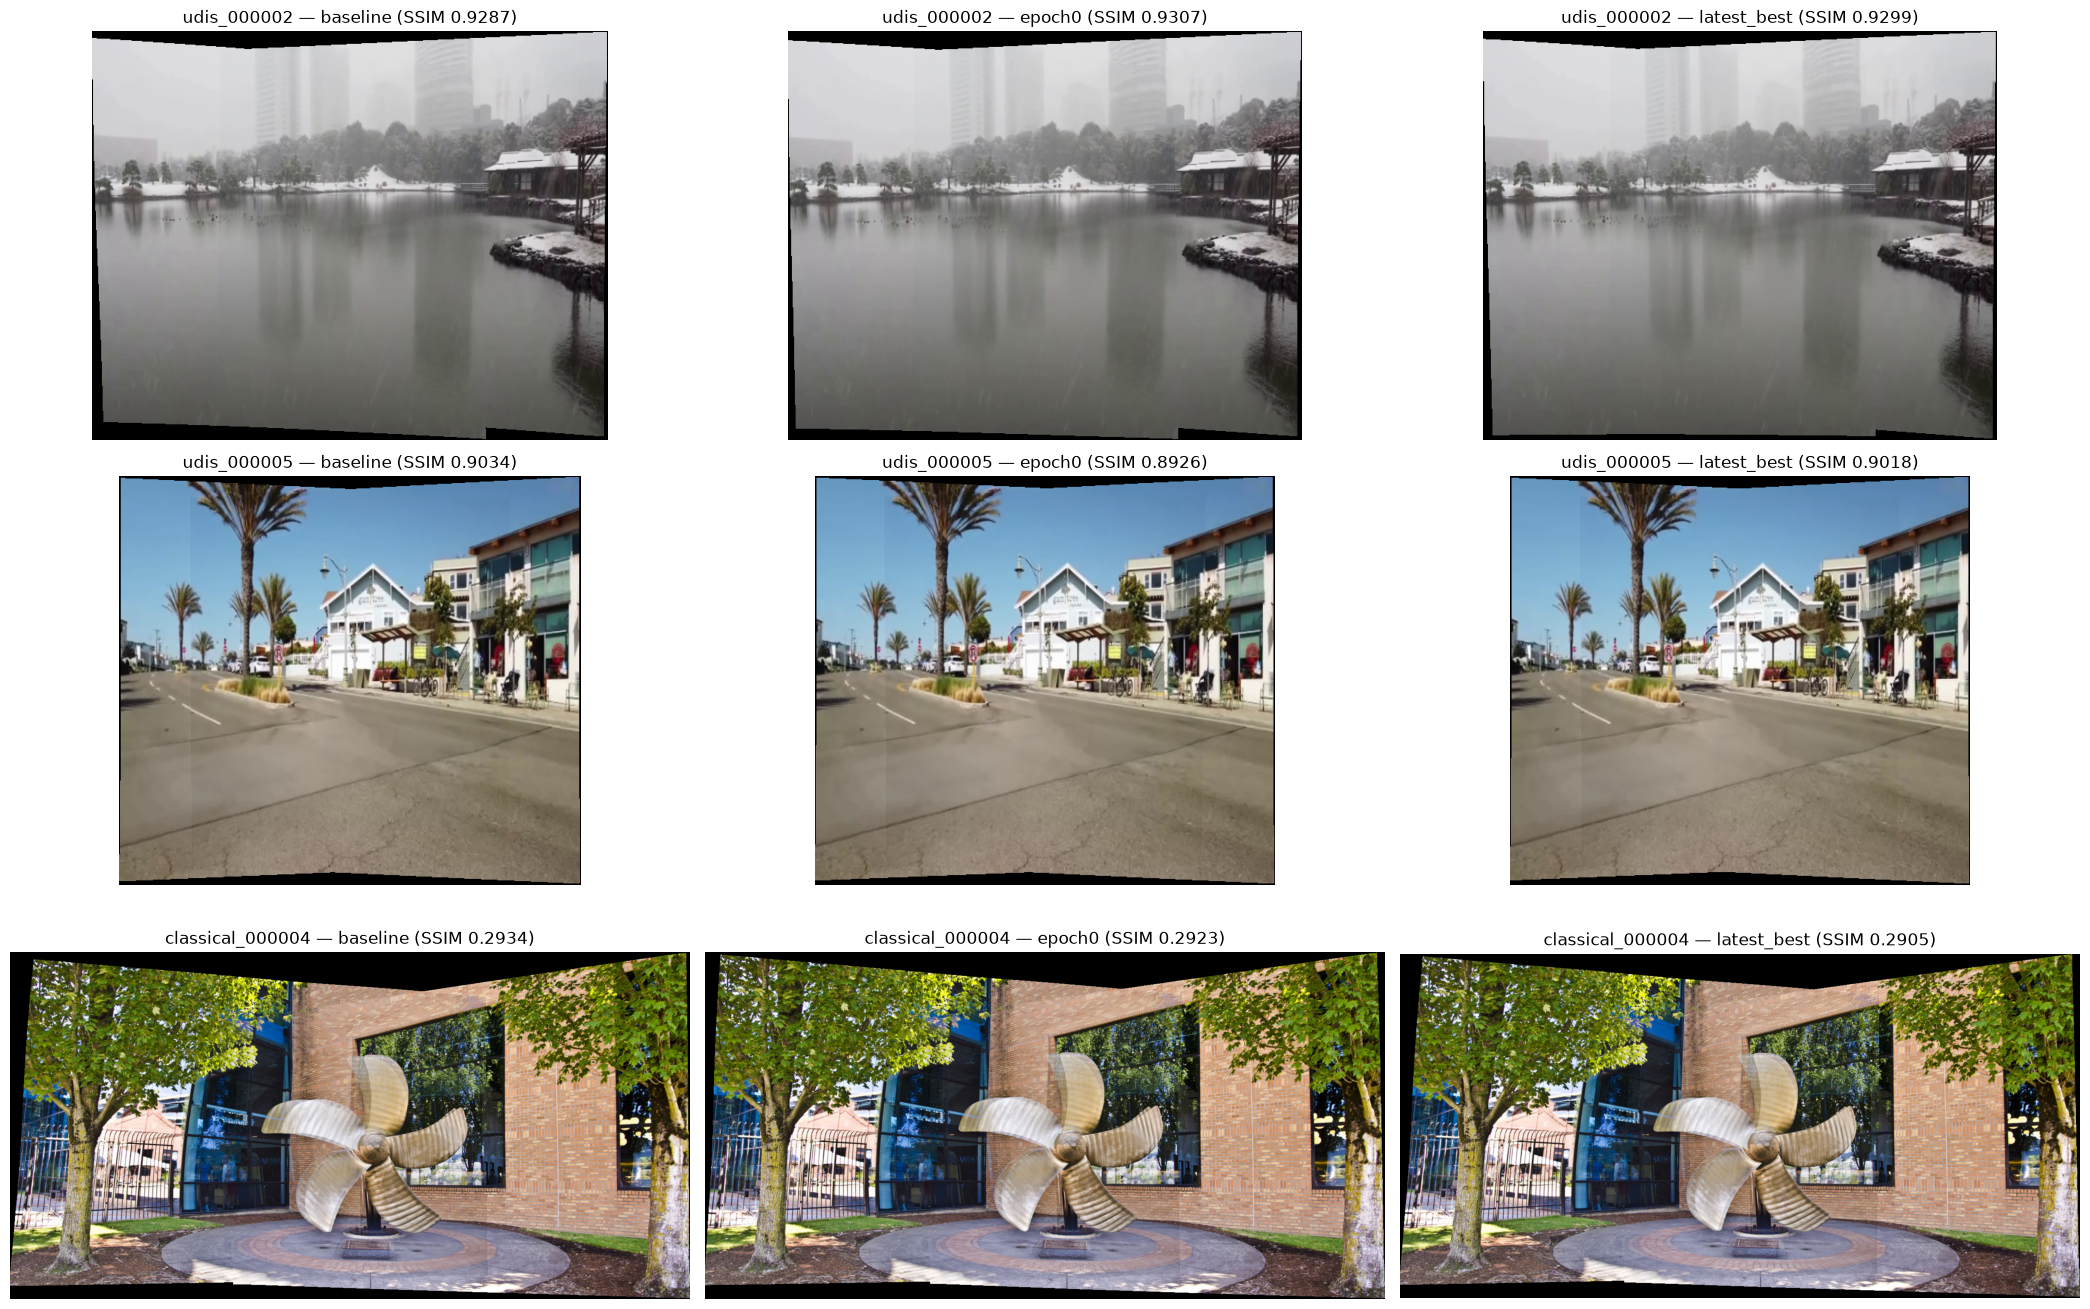

In [7]:
figure, axes = plt.subplots(len(DATASETS), len(networks), figsize=(7 * len(networks), 4.5 * len(DATASETS)))
for column, model_name in enumerate(networks):
    for row, sample_name in enumerate(DATASETS):
        axis = np.ravel(axes)[row * len(networks) + column]
        outcome = results.get((model_name, sample_name))
        if outcome is None:
            axis.axis("off")
            continue
        axis.imshow(outcome["fused_rgb"])
        axis.set_title(f"{sample_name} — {model_name} (SSIM {outcome['ssim']:.4f})")
        axis.axis("off")
figure.tight_layout()
figure.savefig(FIG_DIR / "stitching_epoch0_vs_baseline.png", dpi=100)
plt.show()

## 4. Summary

In [8]:
header = "| sample | " + " | ".join(networks) + " |"
separator = "|---" * (len(networks) + 1) + "|"
rows = [header, separator]
for sample_name in DATASETS:
    cells = []
    for model_name in networks:
        outcome = results.get((model_name, sample_name))
        cells.append("skip" if outcome is None else f"{outcome['ssim']:.4f} / {outcome['psnr']:.2f}")
    rows.append(f"| {sample_name} | " + " | ".join(cells) + " |")
print("\n".join(rows))

| sample | baseline | epoch0 | latest_best |
|---|---|---|---|
| udis_000002 | 0.9287 / 32.67 | 0.9307 / 32.67 | 0.9299 / 32.52 |
| udis_000005 | 0.9034 / 26.19 | 0.8926 / 25.73 | 0.9018 / 26.14 |
| classical_000004 | 0.2934 / 13.37 | 0.2923 / 13.38 | 0.2905 / 13.41 |
